# 10 · Ensembles of pipelines

**Question.** Within one sequencing center, which combination of 2 to 6 of its 24 pipelines, called with which voting threshold, gives the best F1-score against the high-confidence variant set? Does the configuration chosen on four centers still work on the fifth?

**Reviewer comment.** None.

**Reads.** `data/derived/sets_dict.parquet` (the variant set of each run), `data/reference/TestCases.csv` and the truth VCF `data/truth/hc_bed_filtered.recode.vcf`. It never reads `data/raw/`; no run VCF is parsed.

**Method.**
1. Each center has 24 pipelines: 2 mappers x 3 callers x 2 trimming x 2 base recalibration. Environment and duplicate handling are dropped, one run per pipeline (the first in run order, `io.pipeline_runs`, as notebook 08).
2. Per center, every combination of n = 2 to 6 pipelines is enumerated: 276 + 2,024 + 10,626 + 42,504 + 134,596 = 190,026 combinations. For every voting threshold k = 1 to n, the ensemble keeps the variants called by at least k of its pipelines; its precision, recall and F1 are computed against the truth set (`metrics.subset_vote_search`, `metrics.scores_from_counts`). The 24 individual pipelines are n = 1.
3. Leave-one-center-out (LOCO): for each center in turn, the mean F1 over the other four centers is computed for every combination and threshold (a combination is the same 6 pipeline settings in every center); the highest is the chosen configuration (`metrics.best_configuration`, the first maximum). It is then scored on the held-out center, against the individual pipeline with the highest training F1.

**SomaticSniper asymmetry.** SomaticSniper VCFs have `FILTER = .` on every record, so the PASS filter is not applied to them (legacy behaviour); Mutect and Strelka are PASS-filtered. Every ensemble that contains a SomaticSniper pipeline inherits this.

**Produces** (`results/10_ensemble/`):
- `tables/pipelines.csv`: the 24 pipelines (settings and index) and `tables/individual_f1.csv`: precision, recall and F1 of each in each center.
- `tables/ensemble_summary.csv`: per center, size n and threshold k: number of combinations, F1 minimum, median and maximum, and the best combination with its precision and recall.
- `tables/ensemble_best.csv`: per center and size, the best threshold and combination, and its gain over the best individual pipeline.
- `tables/loco_folds.csv`, `tables/loco_summary.csv`: the leave-one-center-out selection, held-out scores, and the overlap of the five selected ensembles.
- `figures/ensemble_f1_grid`: F1 of individual pipelines and of every combination at every threshold, one row per center.

**Reproduction.** The legacy notebook has no ensemble analysis, so there is no legacy table. Parity checks that the vectorised search equals the ported legacy functions (`ensemble_call`, `precision`, `recall`, `f1`) on every individual pipeline, on the best combination of every center and size, and on a seeded sample of combinations; and compares the results with the values in the manuscript text. The audit says which reproduce.

**Does not.** Change the pipeline definition, weight the votes, choose a threshold per center, or use the indel runs.

## Imports

In [1]:
import sys
from pathlib import Path

try:
    import swb  # noqa: F401
except ImportError:  # swb is not pip-installed: use the repository's src/ (notebooks run from notebooks/)
    sys.path.insert(0, str(Path.cwd().parent / "src"))

import itertools

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from swb import audit, config, io, metrics, viz

## Config

In [2]:
OUT = config.results_dir("10_ensemble")
STAGE = audit.Stage(OUT / ".staging")

EXPECTED_RUNS = 480
LEVELS = config.FACTOR_LEVELS
PIPELINE = config.PIPELINE_FACTORS
SETTINGS = [f for f in PIPELINE if f != "Sample"]
CENTERS = LEVELS["Sample"]
SIZES = (2, 3, 4, 5, 6)              # pipelines per ensemble; 1 is the individual pipeline
SEED = 0
LINES_PER_PANEL = 2000               # combinations that get a grey line in the figure (all points are drawn)
# Values in the manuscript text (given by the author)
MANUSCRIPT = {
    "combinations": 190026,           # per center, sizes 2 to 6
    "best_f1_size_2": 0.9261,
    "best_f1_size_6": 0.9374, "size_6_center": "IL", "size_6_threshold": 4,
    "loco_selected": (6, 4),          # (n, k) chosen in all five folds
    "loco_f1_mean": 0.89, "loco_f1_sd": 0.043, "loco_gain_mean": 0.018,
    "shared_members": 2, "jaccard_mean": 0.50,
    "il_fold_f1": 0.93, "il_fold_gap": 0.0045, "il_fold_shared": 2,
}

## Load + validate

In [3]:
assert config.SETS_PARQUET.exists(), "run 01_variant_sets first"
sets = io.load_sets(config.SETS_PARQUET)
assert len(sets) == EXPECTED_RUNS and all(sets.values()), "the cache does not hold {} non-empty runs".format(EXPECTED_RUNS)

meta = pd.read_csv(config.METADATA_CSV)
assert list(meta.columns) == config.METADATA_COLUMNS, list(meta.columns)
runs = io.study_runs(meta, sets, LEVELS, rename=config.METADATA_RENAME).reset_index()
assert runs["run"].is_monotonic_increasing  # the row order that "first run of a group" refers to

truth = io.truth_set(str(config.TRUTH_VCF))
assert len(truth) > 0
print("{} runs, {} truth variants".format(len(runs), len(truth)))

480 runs, 1161 truth variants


## Analysis

In [4]:
chosen = io.pipeline_runs(runs, PIPELINE)
assert len(chosen) == 120 and chosen["run"].is_unique
per_center = {c: chosen[chosen["Sample"] == c].sort_values(SETTINGS).reset_index(drop=True) for c in CENTERS}
assert all(len(r) == 24 for r in per_center.values())
# Row i is the same pipeline setting in every center: that is what lets LOCO average a combination over centers
pipelines = per_center[CENTERS[0]][SETTINGS].copy()
assert all(r[SETTINGS].equals(pipelines) for r in per_center.values())
pipelines.insert(0, "pipeline", range(24))
pipelines["label"] = ["{}+{} trim {} recal {}".format(r.Mapper, r.VariantCaller, r.isTrimmed, r.baseRecalibration)
                      for r in pipelines.itertuples()]
pipelines

,pipeline,Mapper,VariantCaller,isTrimmed,baseRecalibration,label
0,0,BOWTIE,Mutect,NO,NO,BOWTIE+Mutect trim NO recal NO
1,1,BOWTIE,Mutect,NO,YES,BOWTIE+Mutect trim NO recal YES
2,2,BOWTIE,Mutect,YES,NO,BOWTIE+Mutect trim YES recal NO
3,3,BOWTIE,Mutect,YES,YES,BOWTIE+Mutect trim YES recal YES
4,4,BOWTIE,SomaticSniper,NO,NO,BOWTIE+SomaticSniper trim NO recal NO
5,5,BOWTIE,SomaticSniper,NO,YES,BOWTIE+SomaticSniper trim NO recal YES
6,6,BOWTIE,SomaticSniper,YES,NO,BOWTIE+SomaticSniper trim YES recal NO
7,7,BOWTIE,SomaticSniper,YES,YES,BOWTIE+SomaticSniper trim YES recal YES
8,8,BOWTIE,Strelka,NO,NO,BOWTIE+Strelka trim NO recal NO
9,9,BOWTIE,Strelka,NO,YES,BOWTIE+Strelka trim NO recal YES


In [5]:
subsets = {}     # size -> (n_combinations, size) pipeline indices, the same in every center
counts = {}      # (center, size) -> (n_called, true positives), each (n_combinations, size): column k - 1 is the threshold k
scores = {}      # (center, size) -> (precision, recall, f1), same shape
for c in CENTERS:
    matrix, truth_columns = metrics.vote_matrix([sets[k] for k in per_center[c]["TestCaseNo"]], truth)
    for size in (1,) + SIZES:
        found, n_called, tp = metrics.subset_vote_search(matrix, truth_columns, size)
        assert size not in subsets or (subsets[size] == found).all()
        subsets[size] = found
        counts[(c, size)] = (n_called, tp)
        scores[(c, size)] = metrics.scores_from_counts(n_called, tp, len(truth))
n_combinations = sum(len(subsets[s]) for s in SIZES)
assert n_combinations == MANUSCRIPT["combinations"], n_combinations
assert not any(np.isnan(s[2]).any() for s in scores.values()), "an ensemble calls nothing"
print("{:,} combinations per center, {:,} (combination, threshold) scores per center".format(
    n_combinations, sum(len(subsets[s]) * s for s in SIZES)))

190,026 combinations per center, 1,069,224 (combination, threshold) scores per center


In [6]:
individual = pd.DataFrame([(c, i, *(a[i, 0] for a in scores[(c, 1)])) for c in CENTERS for i in range(24)],
                          columns=["center", "pipeline", "precision", "recall", "f1"])
best_individual = individual.groupby("center")["f1"].max()

rows = []
for c in CENTERS:
    for size in (1,) + SIZES:
        precision, recall, f1 = scores[(c, size)]
        n_called = counts[(c, size)][0]
        for k in range(1, size + 1):
            i = int(np.nanargmax(f1[:, k - 1]))
            rows.append({"center": c, "size": size, "k": k, "n_combinations": len(f1), "f1_min": f1[:, k - 1].min(),
                         "f1_median": np.median(f1[:, k - 1]), "f1_max": f1[i, k - 1],
                         "best_combination": ";".join(str(p) for p in subsets[size][i]),
                         "best_precision": precision[i, k - 1], "best_recall": recall[i, k - 1],
                         "best_n_called": int(n_called[i, k - 1])})
ensemble_summary = pd.DataFrame(rows)

best_rows = []
for c in CENTERS:
    for size in (1,) + SIZES:
        sub = ensemble_summary[(ensemble_summary["center"] == c) & (ensemble_summary["size"] == size)]
        top = sub.loc[sub["f1_max"].idxmax()]                       # the first maximum: the lowest threshold
        best_rows.append({"center": c, "size": size, "k": int(top["k"]), "f1": top["f1_max"],
                          "precision": top["best_precision"], "recall": top["best_recall"],
                          "combination": top["best_combination"],
                          "gain_over_best_individual": top["f1_max"] - best_individual[c]})
ensemble_best = pd.DataFrame(best_rows)
best_by_size = ensemble_best.groupby("size")["f1"].max()
ensemble_best[ensemble_best["size"].isin([1, 2, 6])].round(4)

,center,size,k,f1,precision,recall,combination,gain_over_best_individual
0,EA,1,1,0.8979,0.9307,0.8674,3,0.0000
1,EA,2,2,0.9188,0.9537,0.8863,13;21,0.0208
5,EA,6,4,0.9210,0.9677,0.8786,1;9;13;14;19;23,0.0231
6,FD,1,1,0.8316,0.8956,0.7761,3,0.0000
7,FD,2,2,0.8432,0.9267,0.7735,3;23,0.0116
11,FD,6,4,0.8577,0.9469,0.7838,0;3;11;12;17;21,0.0261
12,IL,1,1,0.9218,0.9759,0.8734,1,0.0000
13,IL,2,2,0.9261,0.9845,0.8742,3;21,0.0043
17,IL,6,4,0.9374,0.9830,0.8958,0;1;13;15;17;22,0.0155
18,LL,1,1,0.8361,0.9257,0.7623,15,0.0000


In [7]:
def members_of(size, row):
    return set(int(p) for p in subsets[size][row])

folds = []
for held in CENTERS:
    train = [c for c in CENTERS if c != held]
    mean_train = {size: np.mean([scores[(c, size)][2] for c in train], axis=0) for size in SIZES}
    size, k, row, train_f1 = metrics.best_configuration(mean_train)
    precision, recall, f1 = (a[row, k - 1] for a in scores[(held, size)])
    single_train = np.mean([scores[(c, 1)][2][:, 0] for c in train], axis=0)
    single = int(np.argmax(single_train))
    single_f1 = scores[(held, 1)][2][single, 0]
    folds.append({"held_out": held, "size": size, "k": k, "combination": ";".join(str(p) for p in sorted(members_of(size, row))),
                  "train_f1": train_f1, "held_out_precision": precision, "held_out_recall": recall, "held_out_f1": f1,
                  "best_single_pipeline": single, "best_single_held_out_f1": single_f1, "gain": f1 - single_f1})
loco_folds = pd.DataFrame(folds)
fold_members = [set(int(p) for p in s.split(";")) for s in loco_folds["combination"]]
shared_members = sorted(set.intersection(*fold_members))
jaccard = [len(a & b) / len(a | b) for a, b in itertools.combinations(fold_members, 2)]

# The configuration reported for Illumina: its best 6-pipeline ensemble, and the fold that never saw Illumina
il_best = ensemble_best[(ensemble_best["center"] == "IL") & (ensemble_best["size"] == 6)].iloc[0]
il_best_members = set(int(p) for p in il_best["combination"].split(";"))
il_fold = loco_folds[loco_folds["held_out"] == "IL"].iloc[0]
loco_summary = pd.DataFrame([{
    "folds": len(loco_folds), "folds_choosing_manuscript_configuration": int(
        ((loco_folds["size"] == MANUSCRIPT["loco_selected"][0]) & (loco_folds["k"] == MANUSCRIPT["loco_selected"][1])).sum()),
    "held_out_f1_mean": loco_folds["held_out_f1"].mean(), "held_out_f1_sd": loco_folds["held_out_f1"].std(ddof=1),
    "held_out_f1_sd_ddof0": loco_folds["held_out_f1"].std(ddof=0),
    "gain_mean": loco_folds["gain"].mean(), "gain_min": loco_folds["gain"].min(), "gain_max": loco_folds["gain"].max(),
    "shared_members_all_folds": len(shared_members), "shared_member_pipelines": ";".join(str(p) for p in shared_members),
    "jaccard_mean": float(np.mean(jaccard)), "jaccard_pairs": len(jaccard),
    "il_best_f1": il_best["f1"], "il_best_k": int(il_best["k"]), "il_fold_f1": il_fold["held_out_f1"],
    "il_fold_gap": il_best["f1"] - il_fold["held_out_f1"],
    "il_fold_gap_rounded_values": round(round(il_best["f1"], 4) - round(il_fold["held_out_f1"], 4), 4),
    "il_fold_shared_with_best": len(set(int(p) for p in il_fold["combination"].split(";")) & il_best_members),
    "n_combinations_searched": n_combinations,
}])
loco_folds.round(4)

,held_out,size,k,combination,train_f1,held_out_precision,held_out_recall,held_out_f1,best_single_pipeline,best_single_held_out_f1,gain
0,EA,6,4,3;11;13;15;17;21,0.8842,0.9597,0.8820,0.9192,3,0.8979,0.0213
1,FD,6,4,3;9;13;15;16;21,0.9004,0.9202,0.7941,0.8525,3,0.8316,0.0210
2,IL,6,4,3;11;13;14;17;21,0.8803,0.9847,0.8863,0.9329,3,0.9201,0.0128
3,LL,6,4,1;3;13;17;19;23,0.9035,0.9649,0.7339,0.8337,3,0.8233,0.0104
4,NC,6,4,3;11;13;15;17;21,0.8881,0.9549,0.8570,0.9033,3,0.8808,0.0225


## Save tables

Written to staging; moved to `results/10_ensemble/` only if parity passes.

In [8]:
io.write_csv(pipelines, STAGE.path(OUT / "tables" / "pipelines.csv"), sort_by="pipeline")
io.write_csv(individual, STAGE.path(OUT / "tables" / "individual_f1.csv"), sort_by=["center", "pipeline"])
io.write_csv(ensemble_summary, STAGE.path(OUT / "tables" / "ensemble_summary.csv"), sort_by=["center", "size", "k"])
io.write_csv(ensemble_best, STAGE.path(OUT / "tables" / "ensemble_best.csv"), sort_by=["center", "size"])
io.write_csv(loco_folds, STAGE.path(OUT / "tables" / "loco_folds.csv"), sort_by="held_out")
io.write_csv(loco_summary, STAGE.path(OUT / "tables" / "loco_summary.csv"), sort_by="folds")

## Figures

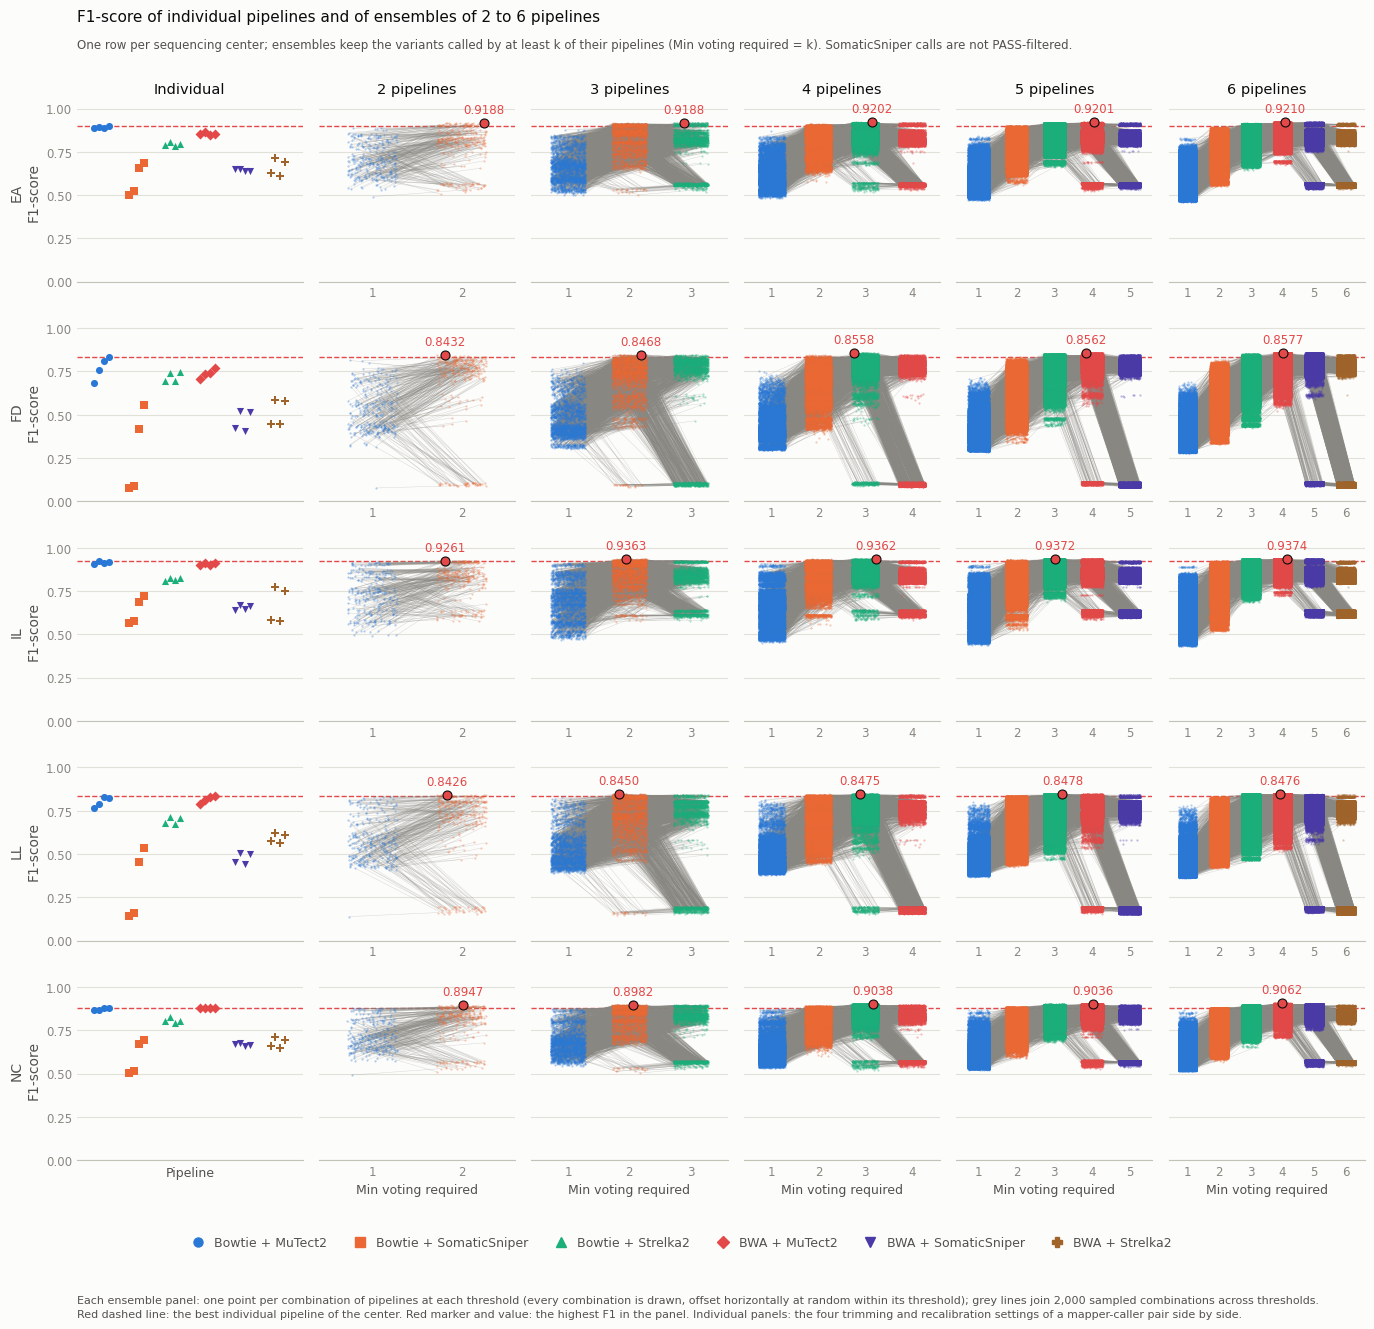

In [9]:
individual_points = pd.concat([per_center[c][PIPELINE].assign(f1=scores[(c, 1)][2][:, 0]) for c in CENTERS])
fig, axes = viz.ensemble_f1_grid(
    individual_points, {(c, s): scores[(c, s)][2] for c in CENTERS for s in SIZES}, best_individual.to_dict(), CENTERS,
    sizes=SIZES, max_lines=LINES_PER_PANEL, seed=SEED,
    title="F1-score of individual pipelines and of ensembles of 2 to 6 pipelines",
    subtitle="One row per sequencing center; ensembles keep the variants called by at least k of their pipelines (Min voting required = k). SomaticSniper calls are not PASS-filtered.",
    footnote="Each ensemble panel: one point per combination of pipelines at each threshold (every combination is drawn, offset horizontally at random within its threshold); grey lines join {:,} sampled combinations across thresholds.\n"
             "Red dashed line: the best individual pipeline of the center. Red marker and value: the highest F1 in the panel. Individual panels: the four trimming and recalibration settings of a mapper-caller pair side by side.".format(LINES_PER_PANEL))
viz.save_fig(fig, STAGE.stem(OUT / "figures" / "ensemble_f1_grid"))
plt.show()

## Parity check

- The vectorised search equals the legacy functions: every individual pipeline, the best combination of every center and size (all thresholds), and a seeded sample of 20 combinations per center and size, each scored with `ensemble_call` and `precision`, `recall`, `f1`, exactly.
- The manuscript text: 190,026 combinations; best F1 0.9261 with 2 pipelines; best F1 0.9374 with 6 pipelines at k = 4, in Illumina; leave-one-center-out chooses n = 6, k = 4 in all five folds; held-out F1 0.89 (SD 0.043); mean gain 0.018; two pipelines in all five ensembles; mean pairwise Jaccard 0.50; the Illumina fold's F1 0.93, 0.0045 below the reported configuration, sharing 2 of 6 members.

The 0.0045 is the difference of the values rounded to 4 decimals; unrounded it is smaller (the audit gives it). Results are moved out of staging only if every check passes.

In [10]:
parity = audit.Parity()
rng = np.random.RandomState(SEED)

def legacy_scores(center, size, row, k):
    chosen_sets = [sets[key] for key in per_center[center]["TestCaseNo"].iloc[list(subsets[size][row])]]
    called = metrics.ensemble_call(chosen_sets, k, "ge")
    return (len(called), len(called & truth)) + metrics.prf1(called, truth)

checked, mismatch = 0, []
for c in CENTERS:
    for size in (1,) + SIZES:
        rows = set(rng.choice(len(subsets[size]), size=min(20, len(subsets[size])), replace=False).tolist())
        if size == 1:
            rows = set(range(24))
        rows |= {int(np.nanargmax(scores[(c, size)][2][:, k - 1])) for k in range(1, size + 1)}
        for row in sorted(rows):
            for k in range(1, size + 1):
                n_called, tp = (a[row, k - 1] for a in counts[(c, size)])
                got = (int(n_called), int(tp)) + tuple(a[row, k - 1] for a in scores[(c, size)])
                checked += 1
                if got != legacy_scores(c, size, row, k):
                    mismatch.append((c, size, row, k))
parity.check("search == ensemble_call scored with precision, recall and f1 ({:,} (center, combination, threshold) cases)".format(checked),
             not mismatch, "{} differ, first {}".format(len(mismatch), mismatch[:3]))

# The manuscript text
parity.check("{:,} combinations of 2 to 6 of the 24 pipelines per center".format(MANUSCRIPT["combinations"]),
             n_combinations == MANUSCRIPT["combinations"], "{:,}".format(n_combinations))
parity.check("best F1 with 2 pipelines is {}".format(MANUSCRIPT["best_f1_size_2"]),
             round(best_by_size[2], 4) == MANUSCRIPT["best_f1_size_2"], "{:.5f}".format(best_by_size[2]))
best_6 = ensemble_best[ensemble_best["size"] == 6].sort_values("f1", ascending=False).iloc[0]
parity.check("best F1 with 6 pipelines is {} at k = {}, in {} (the highest of the five centers)".format(
    MANUSCRIPT["best_f1_size_6"], MANUSCRIPT["size_6_threshold"], MANUSCRIPT["size_6_center"]),
    round(best_6["f1"], 4) == MANUSCRIPT["best_f1_size_6"] and int(best_6["k"]) == MANUSCRIPT["size_6_threshold"]
    and best_6["center"] == MANUSCRIPT["size_6_center"],
    "{} {:.5f} at k = {}".format(best_6["center"], best_6["f1"], int(best_6["k"])))
parity.check("the best F1 over all sizes and centers is the 6-pipeline one in {}".format(MANUSCRIPT["size_6_center"]),
             best_by_size.idxmax() == 6, "best per size: {}".format(best_by_size.round(4).to_dict()))
parity.check("LOCO chooses n = {}, k = {} in all five folds".format(*MANUSCRIPT["loco_selected"]),
             loco_summary["folds_choosing_manuscript_configuration"].iloc[0] == 5,
             "{}".format(list(zip(loco_folds["size"], loco_folds["k"]))))
parity.check("held-out F1 {} +/- {} (mean, sample SD of the five folds)".format(MANUSCRIPT["loco_f1_mean"], MANUSCRIPT["loco_f1_sd"]),
             round(loco_summary["held_out_f1_mean"].iloc[0], 2) == MANUSCRIPT["loco_f1_mean"]
             and round(loco_summary["held_out_f1_sd"].iloc[0], 3) == MANUSCRIPT["loco_f1_sd"],
             "{:.4f} +/- {:.4f}".format(loco_summary["held_out_f1_mean"].iloc[0], loco_summary["held_out_f1_sd"].iloc[0]))
parity.check("mean gain over the best training individual pipeline is {}".format(MANUSCRIPT["loco_gain_mean"]),
             round(loco_summary["gain_mean"].iloc[0], 3) == MANUSCRIPT["loco_gain_mean"], "{:.4f}".format(loco_summary["gain_mean"].iloc[0]))
parity.check("{} pipelines are in all five selected ensembles".format(MANUSCRIPT["shared_members"]),
             len(shared_members) == MANUSCRIPT["shared_members"], "pipelines {}".format(shared_members))
parity.check("mean pairwise Jaccard of the five ensembles is {}".format(MANUSCRIPT["jaccard_mean"]),
             round(loco_summary["jaccard_mean"].iloc[0], 2) == MANUSCRIPT["jaccard_mean"], "{:.4f}".format(loco_summary["jaccard_mean"].iloc[0]))
parity.check("the Illumina fold scores F1 {}".format(MANUSCRIPT["il_fold_f1"]), round(il_fold["held_out_f1"], 2) == MANUSCRIPT["il_fold_f1"],
             "{:.5f}".format(il_fold["held_out_f1"]))
parity.check("the Illumina fold is {} below the reported configuration (difference of the values rounded to 4 decimals)".format(
    MANUSCRIPT["il_fold_gap"]), loco_summary["il_fold_gap_rounded_values"].iloc[0] == MANUSCRIPT["il_fold_gap"],
    "rounded values {:.4f}; unrounded {:.5f}".format(loco_summary["il_fold_gap_rounded_values"].iloc[0], loco_summary["il_fold_gap"].iloc[0]))
parity.check("the Illumina fold shares {} of 6 members with the reported configuration".format(MANUSCRIPT["il_fold_shared"]),
             loco_summary["il_fold_shared_with_best"].iloc[0] == MANUSCRIPT["il_fold_shared"],
             "{}".format(loco_summary["il_fold_shared_with_best"].iloc[0]))
parity.skip("the tables and the figure", "the legacy notebook has no ensemble analysis: there is no recorded legacy output")

parity.finish(OUT / "audit" / "parity.txt", STAGE)

parity: PASS (13 checks, 1 skipped)
PASS  search == ensemble_call scored with precision, recall and f1 (2,562 (center, combination, threshold) cases)  [0 differ, first []]
PASS  190,026 combinations of 2 to 6 of the 24 pipelines per center  [190,026]
PASS  best F1 with 2 pipelines is 0.9261  [0.92609]
PASS  best F1 with 6 pipelines is 0.9374 at k = 4, in IL (the highest of the five centers)  [IL 0.93736 at k = 4]
PASS  the best F1 over all sizes and centers is the 6-pipeline one in IL  [best per size: {1: 0.9218, 2: 0.9261, 3: 0.9363, 4: 0.9362, 5: 0.9372, 6: 0.9374}]
PASS  LOCO chooses n = 6, k = 4 in all five folds  [[(6, 4), (6, 4), (6, 4), (6, 4), (6, 4)]]
PASS  held-out F1 0.89 +/- 0.043 (mean, sample SD of the five folds)  [0.8883 +/- 0.0431]
PASS  mean gain over the best training individual pipeline is 0.018  [0.0176]
PASS  2 pipelines are in all five selected ensembles  [pipelines [3, 13]]
PASS  mean pairwise Jaccard of the five ensembles is 0.5  [0.4962]
PASS  the Illumina fol

## Audit summary

In [11]:
s = loco_summary.iloc[0]
lines = [
    "runs: {}; pipelines: {} (24 per center, one run per pipeline); truth variants: {}".format(len(runs), len(chosen), len(truth)),
    "combinations of 2 to 6 pipelines per center: {:,}; scored at every threshold k = 1 to n, {:,} scores per center".format(
        n_combinations, sum(len(subsets[z]) * z for z in SIZES)),
    "",
    "best F1 by number of pipelines (over centers and thresholds): " + ", ".join(
        "{}: {:.4f}".format(z, v) for z, v in best_by_size.items()),
    "best 6-pipeline ensemble: {} F1 {:.5f} at k = {}; best individual pipeline there {:.5f}".format(
        best_6["center"], best_6["f1"], int(best_6["k"]), best_individual[best_6["center"]]),
    "best threshold k at 6 pipelines by center: " + ", ".join(
        "{} {}".format(r.center, r.k) for r in ensemble_best[ensemble_best["size"] == 6].itertuples()),
    "",
    "leave-one-center-out ({} folds):".format(s["folds"]),
    "  selected (n, k) per held-out center: " + ", ".join("{} ({}, {})".format(r.held_out, r.size, r.k) for r in loco_folds.itertuples()),
    "  held-out F1 {:.4f} +/- {:.4f} (sample SD; {:.4f} with n in the denominator); mean gain over the best training pipeline {:+.4f} (min {:+.4f}, max {:+.4f})".format(
        s["held_out_f1_mean"], s["held_out_f1_sd"], s["held_out_f1_sd_ddof0"], s["gain_mean"], s["gain_min"], s["gain_max"]),
    "  pipelines in all five selected ensembles: {}; mean pairwise Jaccard {:.3f} over {} pairs".format(
        s["shared_member_pipelines"], s["jaccard_mean"], s["jaccard_pairs"]),
    "  Illumina fold: F1 {:.5f}, {:.5f} below the best Illumina 6-pipeline ensemble ({:.5f}, k = {}); shares {} of 6 members".format(
        s["il_best_f1"] - s["il_fold_gap"], s["il_fold_gap"], s["il_best_f1"], s["il_best_k"], s["il_fold_shared_with_best"]),
    "  the manuscript's 0.0045 is the difference of the 4-decimal values ({:.4f}); unrounded it is {:.5f}".format(
        s["il_fold_gap_rounded_values"], s["il_fold_gap"]),
    "",
    "all manuscript values above reproduce; the legacy notebook has no ensemble analysis, so nothing is compared with a legacy table",
    "the vectorised search equals ensemble_call + precision, recall, f1 exactly on {:,} checked cases".format(checked),
    "ties: the first maximum wins (smallest n, then lowest combination index, then lowest k); combination indices follow itertools.combinations over the 24 pipelines of pipelines.csv",
    "SomaticSniper is not PASS-filtered (FILTER is '.' on every record; legacy exemption preserved); ensembles containing it inherit this",
    "figure: all points drawn; the grey lines join a seeded sample of {:,} combinations per panel; horizontal offsets are seeded".format(LINES_PER_PANEL),
    "",
    "python {} | pandas {} | numpy {}".format(sys.version.split()[0], pd.__version__, np.__version__),
]
(OUT / "audit").mkdir(parents=True, exist_ok=True)
(OUT / "audit" / "summary.txt").write_text("\n".join(lines) + "\n")
print("\n".join(lines))

runs: 480; pipelines: 120 (24 per center, one run per pipeline); truth variants: 1161
combinations of 2 to 6 pipelines per center: 190,026; scored at every threshold k = 1 to n, 1,069,224 scores per center

best F1 by number of pipelines (over centers and thresholds): 1: 0.9218, 2: 0.9261, 3: 0.9363, 4: 0.9362, 5: 0.9372, 6: 0.9374
best 6-pipeline ensemble: IL F1 0.93736 at k = 4; best individual pipeline there 0.92182
best threshold k at 6 pipelines by center: EA 4, FD 4, IL 4, LL 3, NC 4

leave-one-center-out (5 folds):
  selected (n, k) per held-out center: EA (6, 4), FD (6, 4), IL (6, 4), LL (6, 4), NC (6, 4)
  held-out F1 0.8883 +/- 0.0431 (sample SD; 0.0386 with n in the denominator); mean gain over the best training pipeline +0.0176 (min +0.0104, max +0.0225)
  pipelines in all five selected ensembles: 3;13; mean pairwise Jaccard 0.496 over 10 pairs
  Illumina fold: F1 0.93291, 0.00445 below the best Illumina 6-pipeline ensemble (0.93736, k = 4); shares 2 of 6 members
  the manu